In [1]:
!pip install gensim

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

In [3]:
df = pd.read_csv("df_final_final_add.csv")

print(df.shape)
df.head()

(5037, 16)


,name,title,context,date,year,full_text,cleaned_tokens,text_length,token_count,cleaned_tokens_no_name,token_count_no_name,cleaned_tokens_final,token_count_final,cleaned_tokens_analysis,token_count_analysis,cleaned_tokens_add
0,메모러블모먼트,"둔촌동역카페 메모러블모먼트 메뉴 추천, 강동구 블루리본카페 올림픽공원카페 후기",메모러블모먼트 ✔️서울 강동구 양재대로 83길 14 ✔️5호선 둔촌동역 3번 출구에...,2주 전,2026,"둔촌동역카페 메모러블모먼트 메뉴 추천, 강동구 블루리본카페 올림픽공원카페 후기 메모...",둔촌동역 메모 러블 모먼트 메뉴 블루리본 올림픽 공원 메모 러블 모먼트 양재대로 호...,262,36,둔촌동역 메뉴 블루리본 올림픽 공원 양재대로 호선 둔촌동역 출구 영업 시간 블루리본...,27,둔촌동역 메뉴 블루리본 올림픽 공원 양재대로 둔촌동역 출구 블루리본 맛집 주차 공간...,23,메뉴 블루리본 블루리본 공간 협소 한살림 유료 도보 블루리본 우연히,10,메뉴 블루리본 블루리본 공간 협소 유료 도보 블루리본
1,메모러블모먼트,강동구 분위기 좋은 카페 메모러블모먼트 블루리본 디저트 솔직 후기,특히 아몬드가 인상적이어서 디저트 메뉴를 함께 즐기기 좋은 곳이었다. 분위기도 조용...,2026.03.22.,2026,강동구 분위기 좋은 카페 메모러블모먼트 블루리본 디저트 솔직 후기 특히 아몬드가 인...,분위기 좋다 메모 러블 모먼트 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 함께 ...,198,32,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 함께 좋다 분위기 조용하...,26,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 좋다 분위기 조용하다 깔...,25,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 좋다 분위기 조용하다 깔...,24,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 좋다 분위기 조용하다 깔...
2,메모러블모먼트,올림픽공원 근처 둔촌동 카페 메모러블모먼트 Memorable Moment 후기,내돈내산 둔촌동 카페 메모러블 모먼트 방문 후기. 메모러블 모먼트라는 카페에 다녀왔...,2026.07.10.,2026,올림픽공원 근처 둔촌동 카페 메모러블모먼트 Memorable Moment 후기 내돈...,올림픽 공원 근처 메모 러블 모먼트 메모 러블 모먼트 메모 러블 모먼트 골목 국민 ...,241,38,올림픽 공원 근처 골목 국민 떡볶이 같다 건물 주차장 따로 없다 올림픽 공원 가깝다...,26,올림픽 공원 골목 국민 떡볶이 건물 주차장 따로 올림픽 공원 가깝다 저희 올림픽 공...,20,국민 떡볶이 따로 가깝다 저희 산책 프랜차이즈 손님 생각,9,국민 떡볶이 따로 가깝다 저희 산책 프랜차이즈 손님 생각
3,메모러블모먼트,[둔촌동 카페]메모러블모먼트 | 블루리본 받은 분위기 좋은 카페,메모러블모먼트 서울 강동구 성내동 440-25 월-금 8:30-23:00 토일 8:...,2026.08.01.,2026,[둔촌동 카페]메모러블모먼트 | 블루리본 받은 분위기 좋은 카페 메모러블모먼트 서울...,메모 러블 모먼트 블루리본 분위기 좋다 메모 러블 모먼트 토일 라스트 마감 안녕하다...,252,35,블루리본 분위기 좋다 토일 라스트 마감 안녕하다 루시 이다 근처 우연히 발견 블루리...,29,블루리본 분위기 좋다 토일 라스트 마감 루시 우연히 발견 블루리본 메뉴 생각 다양하...,22,블루리본 분위기 좋다 토일 라스트 마감 루시 우연히 발견 블루리본 메뉴 생각 다양하...,22,블루리본 분위기 좋다 토일 라스트 마감 루시 발견 블루리본 메뉴 생각 다양하다 커피...
4,메모러블모먼트,"[강동구 카페] 찰나의 순간이 기록되는 곳, 메모러블모먼트(Memorable Mom...",강동구에서 이미 감성 카페로 입소문이 자자한 '메모러블모먼트'입니다. 저는 참새가 ...,2026.04.11.,2026,"[강동구 카페] 찰나의 순간이 기록되는 곳, 메모러블모먼트(Memorable Mom...",찰나 순간 기록 메모 러블 모먼트 솔직 이미 감성 소문 자자하다 메모 러블 모먼트 ...,270,43,찰나 순간 기록 솔직 이미 감성 소문 자자하다 이다 참새 방앗간 근처 무조건 이다 ...,37,찰나 순간 기록 솔직 이미 감성 소문 자자하다 참새 방앗간 무조건 양재대로 강동역 ...,29,찰나 순간 기록 솔직 이미 감성 소문 자자하다 참새 방앗간 특징 블루리본 베이 연속...,24,찰나 순간 기록 솔직 이미 감성 소문 자자하다 참새 방앗간 특징 블루리본 베이 연속...


In [4]:
texts_analysis = (
    df['cleaned_tokens_add']
    .dropna()
    .astype(str)
    .apply(lambda x: x.split())
    .tolist()
)

In [5]:
texts_analysis = [
    text for text in texts_analysis
    if len(text) > 0
]

In [6]:
dictionary = corpora.Dictionary(texts_analysis)
dictionary.filter_extremes(
    no_below=5,
    no_above=0.7
)

In [7]:
corpus = [
    dictionary.doc2bow(text)
    for text in texts_analysis
]

In [8]:
final_num_topics = 3 #****토픽수 3

final_lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=final_num_topics,
    random_state=42,
    passes=20,
    iterations=200,
    alpha='auto',
    eta='auto'
)

In [9]:
for topic_id in range(final_num_topics):

    print(f"\n{'='*70}")
    print(f"Topic {topic_id + 1}")
    print(f"{'='*70}")

    topic_words = final_lda_model.show_topic(
        topic_id,
        topn=15
    )

    for word, weight in topic_words:
        print(f"{word:<15} {weight:.4f}")


Topic 1
커피              0.0326
디저트             0.0258
맛있다             0.0232
라떼              0.0177
블루리본            0.0148
원두              0.0136
동반              0.0118
케이크             0.0116
메뉴              0.0112
좋다              0.0098
크림              0.0095
애견              0.0078
두쫀쿠             0.0070
주말              0.0068
에스프레소           0.0067

Topic 2
베이커리            0.0329
에그타르트           0.0244
빵집              0.0242
할인              0.0159
바게트             0.0155
샌드위치            0.0075
베이글             0.0072
본점              0.0062
천호동             0.0052
롯데              0.0052
잠실              0.0050
포장              0.0049
가격              0.0047
순례              0.0047
오픈              0.0045

Topic 3
좋다              0.0363
분위기             0.0224
브런치             0.0218
디저트             0.0160
감성              0.0145
맛있다             0.0114
데이트             0.0114
공간              0.0078
커피              0.0077
내부              0.0075
느낌              0.0070
예쁘다             0.0070
메뉴     

In [10]:
topic_results = []

for topic_id in range(final_num_topics):

    topic_words = final_lda_model.show_topic(
        topic_id,
        topn=15
    )

    words = [word for word, weight in topic_words]

    topic_results.append({
        'Topic': f'Topic {topic_id + 1}',
        'Keywords': ', '.join(words)
    })

topic_results_df = pd.DataFrame(topic_results)

topic_results_df

,Topic,Keywords
0,Topic 1,"커피, 디저트, 맛있다, 라떼, 블루리본, 원두, 동반, 케이크, 메뉴, 좋다, 크..."
1,Topic 2,"베이커리, 에그타르트, 빵집, 할인, 바게트, 샌드위치, 베이글, 본점, 천호동, ..."
2,Topic 3,"좋다, 분위기, 브런치, 디저트, 감성, 맛있다, 데이트, 공간, 커피, 내부, 느..."


In [11]:
document_topic_matrix = np.zeros(
    (len(corpus), final_num_topics)
)

In [12]:
#각 리뷰의 토픽 비율 저장
for i, bow in enumerate(corpus):

    topic_distribution = final_lda_model.get_document_topics(
        bow,
        minimum_probability=0
    )

    for topic_id, probability in topic_distribution:

        document_topic_matrix[i, topic_id] = probability

In [13]:
#토픽 비율 확인
document_topic_matrix[:5]

array([[0.95327657, 0.01433661, 0.03238673],
       [0.44787833, 0.00499283, 0.54712892],
       [0.01852079, 0.01284984, 0.96862936],
       [0.55957228, 0.00596637, 0.43446139],
       [0.79651022, 0.00499694, 0.19849285]])

In [14]:
df_analysis = df[
    ['name', 'cleaned_tokens_add']
].copy()

df_analysis = df_analysis.dropna()

df_analysis['tokens'] = (
    df_analysis['cleaned_tokens_add']
    .astype(str)
    .apply(lambda x: x.split())
)

df_analysis = df_analysis[
    df_analysis['tokens'].apply(len) > 0
].reset_index(drop=True)

In [15]:
df_analysis.head()

,name,cleaned_tokens_add,tokens
0,메모러블모먼트,메뉴 블루리본 블루리본 공간 협소 유료 도보 블루리본,"[메뉴, 블루리본, 블루리본, 공간, 협소, 유료, 도보, 블루리본]"
1,메모러블모먼트,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 좋다 분위기 조용하다 깔...,"[분위기, 좋다, 블루리본, 디저트, 솔직, 아몬드, 인상, 디저트, 메뉴, 좋다,..."
2,메모러블모먼트,국민 떡볶이 따로 가깝다 저희 산책 프랜차이즈 손님 생각,"[국민, 떡볶이, 따로, 가깝다, 저희, 산책, 프랜차이즈, 손님, 생각]"
3,메모러블모먼트,블루리본 분위기 좋다 토일 라스트 마감 루시 발견 블루리본 메뉴 생각 다양하다 커피...,"[블루리본, 분위기, 좋다, 토일, 라스트, 마감, 루시, 발견, 블루리본, 메뉴,..."
4,메모러블모먼트,찰나 순간 기록 솔직 이미 감성 소문 자자하다 참새 방앗간 특징 블루리본 베이 연속...,"[찰나, 순간, 기록, 솔직, 이미, 감성, 소문, 자자하다, 참새, 방앗간, 특징..."


In [16]:
texts_analysis = df_analysis['tokens'].tolist()

dictionary = corpora.Dictionary(texts_analysis)

dictionary.filter_extremes(
    no_below=5,
    no_above=0.7
)

corpus = [
    dictionary.doc2bow(text)
    for text in texts_analysis
]

In [17]:
topic_columns = [
    f'Topic_{i+1}'
    for i in range(final_num_topics)
]

review_topic_df = pd.DataFrame(
    document_topic_matrix,
    columns=topic_columns
)

In [18]:
review_topic_df['name'] = df_analysis['name']

In [19]:
review_topic_df.head()

,Topic_1,Topic_2,Topic_3,name
0,0.953277,0.014337,0.032387,메모러블모먼트
1,0.447878,0.004993,0.547129,메모러블모먼트
2,0.018521,0.012850,0.968629,메모러블모먼트
3,0.559572,0.005966,0.434461,메모러블모먼트
4,0.796510,0.004997,0.198493,메모러블모먼트


In [20]:
cafe_topic_profile = (
    review_topic_df
    .groupby('name')[topic_columns]
    .mean()
)

In [21]:
cafe_topic_profile.head(30)

,Topic_1,Topic_2,Topic_3
name,,,
WAAAH,0.228213,0.057236,0.714551
고스카페,0.214425,0.279651,0.505924
까페항상,0.263258,0.333185,0.403557
드리프트우드,0.068730,0.109933,0.821337
림폴커피,0.342112,0.128191,0.529697
매드베이커리,0.247759,0.248633,0.503607
메모러블모먼트,0.563838,0.030266,0.405896
멜티스,0.626182,0.093086,0.280732
미도리카페,0.645568,0.065893,0.288539


In [22]:
topic_name_mapping = {
    'Topic_1': '커피음료 경험',
    'Topic_2': '디저트베이커리 경험',
    'Topic_3': '공간분위기 경험',
}

In [24]:
cafe_profile_named = cafe_topic_profile.rename(
    columns=topic_name_mapping
)

cafe_profile_named.head(30)

,커피음료 경험,디저트베이커리 경험,공간분위기 경험
name,,,
WAAAH,0.228213,0.057236,0.714551
고스카페,0.214425,0.279651,0.505924
까페항상,0.263258,0.333185,0.403557
드리프트우드,0.068730,0.109933,0.821337
림폴커피,0.342112,0.128191,0.529697
매드베이커리,0.247759,0.248633,0.503607
메모러블모먼트,0.563838,0.030266,0.405896
멜티스,0.626182,0.093086,0.280732
미도리카페,0.645568,0.065893,0.288539


In [25]:
cafe_profile_named.to_csv(
    'cafe_customer_experience_profile.csv',
    encoding='utf-8-sig'
)

In [26]:
cafe_topic_profile.head()

,Topic_1,Topic_2,Topic_3
name,,,
WAAAH,0.228213,0.057236,0.714551
고스카페,0.214425,0.279651,0.505924
까페항상,0.263258,0.333185,0.403557
드리프트우드,0.068730,0.109933,0.821337
림폴커피,0.342112,0.128191,0.529697


In [27]:
cafe_profile_result = cafe_profile_named.copy()

cafe_profile_result['주요 고객 경험 요인'] = (
    cafe_profile_result.idxmax(axis=1)
)

cafe_profile_result.head(30)

,커피음료 경험,디저트베이커리 경험,공간분위기 경험,주요 고객 경험 요인
name,,,,
WAAAH,0.228213,0.057236,0.714551,공간분위기 경험
고스카페,0.214425,0.279651,0.505924,공간분위기 경험
까페항상,0.263258,0.333185,0.403557,공간분위기 경험
드리프트우드,0.068730,0.109933,0.821337,공간분위기 경험
림폴커피,0.342112,0.128191,0.529697,공간분위기 경험
매드베이커리,0.247759,0.248633,0.503607,공간분위기 경험
메모러블모먼트,0.563838,0.030266,0.405896,커피음료 경험
멜티스,0.626182,0.093086,0.280732,커피음료 경험
미도리카페,0.645568,0.065893,0.288539,커피음료 경험


In [28]:
cafe_type_df = cafe_profile_result.copy()

cafe_type_df.head(30)



,커피음료 경험,디저트베이커리 경험,공간분위기 경험,주요 고객 경험 요인
name,,,,
WAAAH,0.228213,0.057236,0.714551,공간분위기 경험
고스카페,0.214425,0.279651,0.505924,공간분위기 경험
까페항상,0.263258,0.333185,0.403557,공간분위기 경험
드리프트우드,0.068730,0.109933,0.821337,공간분위기 경험
림폴커피,0.342112,0.128191,0.529697,공간분위기 경험
매드베이커리,0.247759,0.248633,0.503607,공간분위기 경험
메모러블모먼트,0.563838,0.030266,0.405896,커피음료 경험
멜티스,0.626182,0.093086,0.280732,커피음료 경험
미도리카페,0.645568,0.065893,0.288539,커피음료 경험


In [29]:
type_counts = cafe_type_df['주요 고객 경험 요인'].value_counts()

type_counts

,count
주요 고객 경험 요인,
공간분위기 경험,20
커피음료 경험,9
디저트베이커리 경험,9


In [30]:
# 나눔 고딕 폰트 설치
%cd /content
!wget https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = 'NanumGothic-Regular.ttf'       # 설치한 폰트 경로
fm.fontManager.addfont(font_path)   # 폰트 경로 추가

plt.rcParams['font.family'] = 'NanumGothic' # 사용 폰트 입력
plt.rcParams['axes.unicode_minus'] = False  # 음수 부호 사용

/content
--2026-09-11 00:56:43--  https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google/fonts/main/ofl/nanumgothic/NanumGothic-Regular.ttf [following]
--2026-09-11 00:56:44--  https://raw.githubusercontent.com/google/fonts/main/ofl/nanumgothic/NanumGothic-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2054744 (2.0M) [application/octet-stream]
Saving to: ‘NanumGothic-Regular.ttf’

NanumGothic-Regular 100%[===================>]   1.96M  --.-KB/s    in 0.01s   

2026-09-11 00:56:44 (147 MB/s) - ‘NanumGoth

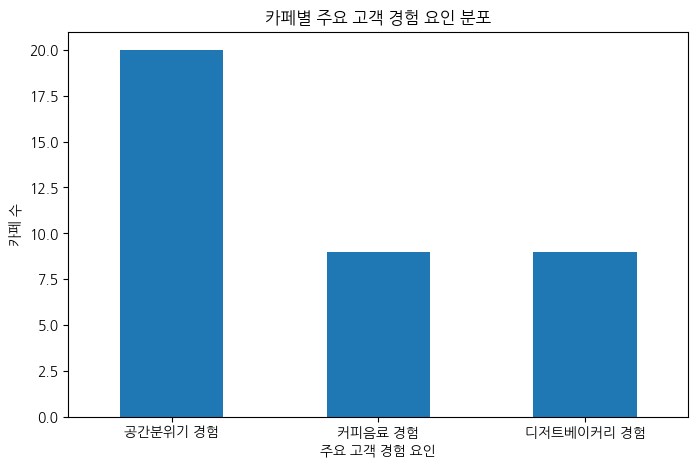

In [31]:
import matplotlib.pyplot as plt

type_counts.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('카페별 주요 고객 경험 요인 분포')
plt.xlabel('주요 고객 경험 요인')
plt.ylabel('카페 수')

plt.xticks(rotation=0)

plt.show()

In [32]:
#****추천 받는 사용자의 선호도 입력
user_preference = {
    '커피음료 경험': 1,
    '디저트베이커리 경험': 5,
    '공간분위기 경험': 3
}

In [33]:
user_vector = np.array([
    user_preference['커피음료 경험'],
    user_preference['디저트베이커리 경험'],
    user_preference['공간분위기 경험']
])

user_vector

array([1, 5, 3])

In [34]:
user_vector = user_vector / user_vector.sum()

user_vector

array([0.11111111, 0.55555556, 0.33333333])

In [35]:
from sklearn.metrics.pairwise import cosine_similarity

In [39]:
cafe_vectors = cafe_profile_named[['커피음료 경험','디저트베이커리 경험','공간분위기 경험']]

In [40]:
similarity_scores = cosine_similarity(
    cafe_vectors,
    user_vector.reshape(1, -1)
)

In [42]:
cafe_profile_named['similarity_score'] = similarity_scores.flatten()

In [45]:
recommendations = (
    cafe_profile_named.reset_index()
    .sort_values(
        'similarity_score',
        ascending=False
    )
    [['name', 'similarity_score'] + ['커피음료 경험','디저트베이커리 경험','공간분위기 경험']]
    .head(5)
)

recommendations

#****추천 받는 사용자의 선호도 입력사항
#    '커피음료 경험': 1,
#    '디저트베이커리 경험': 5,
#    '공간분위기 경험': 3




,name,similarity_score,커피음료 경험,디저트베이커리 경험,공간분위기 경험
17,아티초크라보,0.989872,0.190715,0.510959,0.298326
13,세브,0.983466,0.210579,0.511895,0.277526
22,오뜨르,0.977473,0.218144,0.535649,0.246207
23,오베르캄프,0.965541,0.226994,0.565454,0.207552
34,피터베이커리,0.961654,0.259414,0.464223,0.276363


In [46]:
recommendations.to_csv(
    'recommendations_system.csv',
    encoding='utf-8-sig'
)

In [49]:
recommendations = recommendations.copy()

recommendations['주요 특징'] = (
    recommendations[['커피음료 경험','디저트베이커리 경험','공간분위기 경험']]
    .idxmax(axis=1)
)

recommendations

,name,similarity_score,커피음료 경험,디저트베이커리 경험,공간분위기 경험,주요 특징
17,아티초크라보,0.989872,0.190715,0.510959,0.298326,디저트베이커리 경험
13,세브,0.983466,0.210579,0.511895,0.277526,디저트베이커리 경험
22,오뜨르,0.977473,0.218144,0.535649,0.246207,디저트베이커리 경험
23,오베르캄프,0.965541,0.226994,0.565454,0.207552,디저트베이커리 경험
34,피터베이커리,0.961654,0.259414,0.464223,0.276363,디저트베이커리 경험
